In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestClassifier

# Đường dẫn đến tệp CSV
file_path = "D:/diabetes.csv"  

# Bước 1: Đọc tệp CSV
try:
    data = pd.read_csv(file_path)
    print("Dữ liệu đã được đọc thành công!")
except Exception as e:
    print(f"Lỗi khi đọc tệp: {e}")

Dữ liệu đã được đọc thành công!


In [2]:

# Bước 2: Hiển thị thông tin cơ bản về dữ liệu
print("\nThông tin tổng quan về dữ liệu:")
print(data.info())

print("\nThống kê mô tả dữ liệu:")
print(data.describe(include='all'))


Thông tin tổng quan về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               767 non-null    int64  
 1   Glucose                   767 non-null    int64  
 2   BloodPressure             767 non-null    int64  
 3   SkinThickness             767 non-null    int64  
 4   Insulin                   767 non-null    int64  
 5   BMI                       767 non-null    float64
 6   DiabetesPedigreeFunction  767 non-null    float64
 7   Age                       767 non-null    int64  
 8   Outcome                   767 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Thống kê mô tả dữ liệu:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   767.000000  767.000000     767.000000     767.000000  767.000000   
mean      3.848761  120.9

In [3]:
# Bước 3: Xử lý giá trị bị thiếu và giá trị bằng 0
columns_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Thay thế giá trị bằng 0 bằng giá trị trung bình của từng cột
for col in columns_to_replace:
    data[col] = data[col].replace(0, data[col].mean())

print("\nDữ liệu sau khi xử lý giá trị bằng 0:")
print(data[columns_to_replace].describe())


Dữ liệu sau khi xử lý giá trị bằng 0:
          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  767.000000     767.000000     767.000000  767.000000  767.000000
mean   121.719237      72.257693      26.596714  118.761425   32.453509
std     30.438211      12.123577       9.638762   93.109342    6.879458
min     44.000000      24.000000       7.000000   14.000000   18.200000
25%    100.000000      64.000000      20.522816   79.903520   27.500000
50%    117.000000      72.000000      23.000000   79.903520   32.000000
75%    140.500000      80.000000      32.000000  127.500000   36.600000
max    199.000000     122.000000      99.000000  846.000000   67.100000


In [4]:
# Chia dữ liệu thành đặc trưng (X) và nhãn (y)
X = data.drop(columns=['Outcome'])
y = data['Outcome']

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Áp dụng Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

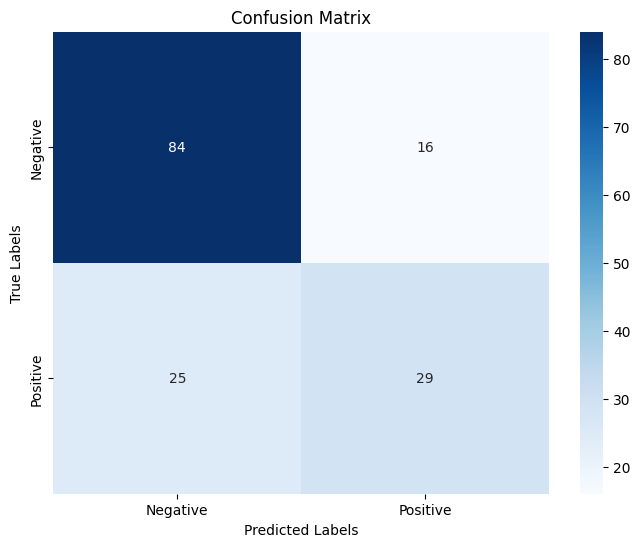

In [7]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [8]:
# Các chỉ số đánh giá
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")


Model Evaluation:
Accuracy: 73.38%
Precision: 64.44%
Recall: 53.70%
F1 Score: 58.59%


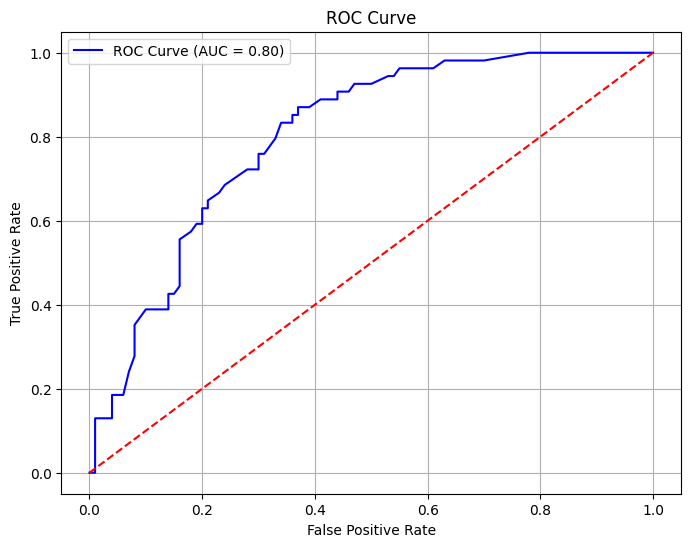

In [9]:
# Bước 8: Vẽ ROC Curve và tính AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()